In [2]:
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

torch.manual_seed(0)

device: cpu


Dans ce notebook, on fait un premier test avec le sample détaillé dans l'overleaf pour voir ce que ça donne. Le réseau est entrainé à prédire le bruit ajouté à $Z_0$, ce qui donne $Z_t$ au temps t.

Génération de données synthétiques

In [42]:
# ============================================================
# Données synthétiques : choix de la loi de X_0
# ============================================================
# Lois disponibles :
#   "gaussian"
#   "gaussian_mixture"       (alias : "mixture")
#   "exponential"
#   "exponential_mixture"
#   "cauchy"
#   "symmetric_exponential"  (alias : "laplace")
# ============================================================
data = "mixture"


mu_x0 = 3.0
var_x0 = 0.4

sigma_base = 1.0
eps_mean = 3.0 / sigma_base if sigma_base != 0 else 0.0

n_samples = 30000


# ============================================================
# Paramètres gaussienne simple
# X_0 ~ N(mu_x0, var_x0)
# ============================================================

mu_z0_gaussian = mu_x0 + sigma_base * eps_mean
var_z0_gaussian = var_x0 + sigma_base**2


# ============================================================
# Paramètres mélange de gaussiennes
# ============================================================

gaussian_mixture_weights = torch.tensor(
    [0.7, 0.3],
    dtype=torch.float32,
    device=device,
)

gaussian_mixture_means = torch.tensor(
    [-4.0, 4.0],
    dtype=torch.float32,
    device=device,
)

gaussian_mixture_stds = torch.tensor(
    [0.2, 0.5],
    dtype=torch.float32,
    device=device,
)

# Compatibilité avec les anciens noms
mixture_weights = gaussian_mixture_weights
mixture_means = gaussian_mixture_means
mixture_stds = gaussian_mixture_stds


# ============================================================
# Paramètres exponentielle simple
#
# f(x) = lambda * exp(-lambda*x), x >= 0
# ============================================================

exponential_rate = 2.0


# ============================================================
# Paramètres mélange d'exponentielles
#
# f(x) = sum_k pi_k lambda_k exp(-lambda_k*x), x >= 0
# ============================================================

exponential_mixture_weights = torch.tensor(
    [0.75, 0.25],
    dtype=torch.float32,
    device=device,
)

exponential_mixture_rates = torch.tensor(
    [0.35, 4.00],
    dtype=torch.float32,
    device=device,
)


# ============================================================
# Paramètres Cauchy
#
# f(x ; x0, a)
# = 1 / [pi * a * (1 + ((x-x0)/a)^2)]
# = (1/pi) * a / ((x-x0)^2 + a^2)
#
# C'est la vraie Cauchy : aucune troncature.
# ============================================================

cauchy_x0 = 0.0
cauchy_a = 1.0


# ============================================================
# Paramètres exponentielle symétrisée = Laplace
#
# f(x) = rate/2 * exp(-rate * |x-loc|)
# ============================================================

symmetric_exponential_loc = 0.0
symmetric_exponential_rate = 1.0


# ============================================================
# Alias
# ============================================================

_DATA_ALIASES = {
    "mixture": "gaussian_mixture",
    "laplace": "symmetric_exponential",
    "symmetric_exp": "symmetric_exponential",
    "sym_exponential": "symmetric_exponential",
    "exp_mixture": "exponential_mixture",
}


def _canonical_data_name(name):
    name = _DATA_ALIASES.get(name, name)

    allowed = {
        "gaussian",
        "gaussian_mixture",
        "exponential",
        "exponential_mixture",
        "cauchy",
        "symmetric_exponential",
    }

    if name not in allowed:
        raise ValueError(
            f"Loi inconnue : {name}. "
            f"Choisir parmi {sorted(allowed)}."
        )

    return name


def _check_weights(weights, name):
    if weights.ndim != 1:
        raise ValueError(f"{name} doit être un vecteur 1D.")

    if torch.any(weights < 0):
        raise ValueError(
            f"{name} doit contenir des poids positifs ou nuls."
        )

    if torch.sum(weights) <= 0:
        raise ValueError(
            f"La somme de {name} doit être strictement positive."
        )


def _check_exponential_mixture():
    _check_weights(
        exponential_mixture_weights,
        "exponential_mixture_weights",
    )

    if exponential_mixture_rates.ndim != 1:
        raise ValueError(
            "exponential_mixture_rates doit être un vecteur 1D."
        )

    if (
        len(exponential_mixture_weights)
        != len(exponential_mixture_rates)
    ):
        raise ValueError(
            "Le nombre de poids doit être égal au nombre de taux."
        )

    if torch.any(exponential_mixture_rates <= 0):
        raise ValueError(
            "Tous les taux exponentiels doivent être strictement positifs."
        )


# ============================================================
# Générateurs X_0
# ============================================================

def sample_x0_gaussian(batch_size):
    """X_0 ~ N(mu_x0, var_x0)."""
    if var_x0 <= 0:
        raise ValueError("var_x0 doit être strictement positif.")

    std = math.sqrt(var_x0)

    return mu_x0 + std * torch.randn(
        batch_size,
        1,
        device=device,
    )


def sample_x0_gaussian_mixture(batch_size):
    """X_0 ~ somme_k pi_k N(mu_k, std_k^2)."""
    _check_weights(
        gaussian_mixture_weights,
        "gaussian_mixture_weights",
    )

    if torch.any(gaussian_mixture_stds <= 0):
        raise ValueError(
            "Tous les écarts-types doivent être strictement positifs."
        )

    weights = (
        gaussian_mixture_weights
        / gaussian_mixture_weights.sum()
    )

    component_ids = torch.multinomial(
        weights,
        num_samples=batch_size,
        replacement=True,
    )

    means = gaussian_mixture_means[
        component_ids
    ].reshape(batch_size, 1)

    stds = gaussian_mixture_stds[
        component_ids
    ].reshape(batch_size, 1)

    return means + stds * torch.randn(
        batch_size,
        1,
        device=device,
    )


# Compatibilité avec l'ancien notebook
sample_x0_mixture = sample_x0_gaussian_mixture


def sample_x0_exponential(batch_size):
    """
    X_0 ~ Exp(lambda)

    Support : X_0 >= 0.
    """
    if exponential_rate <= 0:
        raise ValueError(
            "exponential_rate doit être strictement positif."
        )

    rate = torch.tensor(
        exponential_rate,
        dtype=torch.float32,
        device=device,
    )

    return torch.distributions.Exponential(rate).sample(
        (batch_size, 1)
    )


def sample_x0_exponential_mixture(batch_size):
    """
    X_0 ~ somme_k pi_k Exp(lambda_k).

    On choisit d'abord une composante k, puis on tire
    une exponentielle de taux lambda_k.
    """
    _check_exponential_mixture()

    weights = (
        exponential_mixture_weights
        / exponential_mixture_weights.sum()
    )

    component_ids = torch.multinomial(
        weights,
        num_samples=batch_size,
        replacement=True,
    )

    selected_rates = exponential_mixture_rates[
        component_ids
    ].reshape(batch_size, 1)

    uniform = torch.rand(
        batch_size,
        1,
        device=device,
    )

    return -torch.log(
        uniform.clamp_min(1e-12)
    ) / selected_rates


def sample_x0_cauchy(batch_size):
    """
    X_0 ~ Cauchy(x0, a).

    Densité exacte :
    f(x) = 1 / [pi*a*(1 + ((x-x0)/a)^2)].
    """
    if cauchy_a <= 0:
        raise ValueError(
            "cauchy_a doit être strictement positif."
        )

    # Formule inverse exacte :
    # X = x0 + a * tan(pi * (U - 1/2))
    uniform = torch.rand(
        batch_size,
        1,
        device=device,
    )

    return cauchy_x0 + cauchy_a * torch.tan(
        np.pi * (uniform - 0.5)
    )


def sample_x0_symmetric_exponential(batch_size):
    """
    X_0 ~ Laplace(loc, scale = 1/rate).

    C'est une exponentielle symétrisée.
    """
    if symmetric_exponential_rate <= 0:
        raise ValueError(
            "symmetric_exponential_rate doit être strictement positif."
        )

    loc = torch.tensor(
        symmetric_exponential_loc,
        dtype=torch.float32,
        device=device,
    )

    scale = torch.tensor(
        1.0 / symmetric_exponential_rate,
        dtype=torch.float32,
        device=device,
    )

    return torch.distributions.Laplace(
        loc,
        scale,
    ).sample((batch_size, 1))


# ============================================================
# Ajout du bruit d'observation
# ============================================================

def sample_z0_from_x0(x0):
    """
    Z_0 = X_0 + sigma_base * eps_0
    eps_0 ~ N(eps_mean, 1)
    """
    eps0 = eps_mean + torch.randn_like(x0)

    return x0 + sigma_base * eps0


def sample_joint_data(batch_size, data):
    """
    Retourne :
      X_0 : donnée cible avant bruit
      Z_0 : donnée observée par le DDPM
    """
    data = _canonical_data_name(data)

    samplers = {
        "gaussian": sample_x0_gaussian,
        "gaussian_mixture": sample_x0_gaussian_mixture,
        "exponential": sample_x0_exponential,
        "exponential_mixture": sample_x0_exponential_mixture,
        "cauchy": sample_x0_cauchy,
        "symmetric_exponential": sample_x0_symmetric_exponential,
    }

    x0 = samplers[data](batch_size)
    z0 = sample_z0_from_x0(x0)

    return x0, z0


def sample_data(batch_size, data=data):
    """
    Le DDPM reçoit Z_0.
    """
    _, z0 = sample_joint_data(batch_size, data)

    return z0


data = _canonical_data_name(data)

print(f"Loi sélectionnée : {data}")

Loi sélectionnée : gaussian_mixture


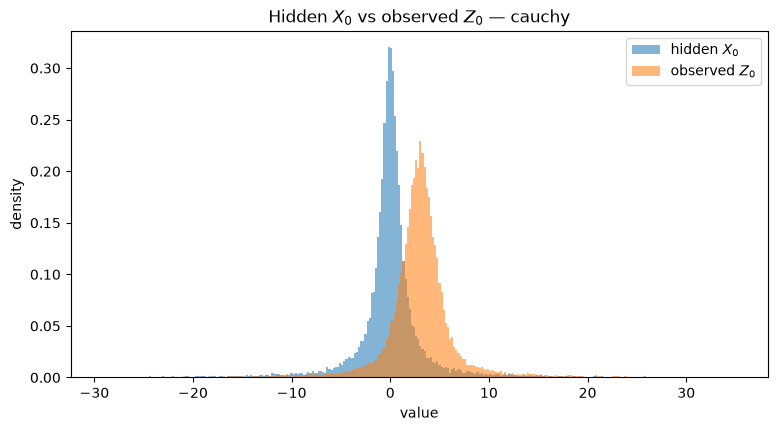

In [53]:
data = "cauchy"  # Choix de la loi pour X_0
if data == "cauchy":


    x0, z0 = sample_joint_data(
        n_samples,
        data=data,
    )

    x0_np = x0.detach().cpu().numpy().ravel()
    z0_np = z0.detach().cpu().numpy().ravel()

    # On définit une fenêtre d'affichage robuste.
    # Les valeurs très extrêmes de Cauchy ne déterminent plus l'axe.
    all_values = np.concatenate([x0_np, z0_np])

    xmin, xmax = np.quantile(
        all_values,
        [0.01, 0.99],
    )

    padding = 0.05 * (xmax - xmin)

    plt.figure(figsize=(9, 4.5))

    plt.hist(
        x0_np,
        bins=300,
        density=True,
        range=(xmin, xmax),
        alpha=0.55,
        label="hidden $X_0$",
    )

    plt.hist(
        z0_np,
        bins=300,
        density=True,
        range=(xmin, xmax),
        alpha=0.55,
        label="observed $Z_0$",
    )

    plt.xlim(
        xmin - padding,
        xmax + padding,
    )

    plt.title(f"Hidden $X_0$ vs observed $Z_0$ — {data}")
    plt.xlabel("value")
    plt.ylabel("density")
    plt.legend()
    plt.show()
else :




    x0, z0 = sample_joint_data(n_samples, data=data)

    x0_np = x0.detach().cpu().numpy()
    z0_np = z0.detach().cpu().numpy()

    plt.figure(figsize=(8, 4))
    plt.hist(x0_np, bins=300, density=True, alpha=0.5, label="hidden X_0")
    plt.hist(z0_np, bins=300, density=True, alpha=0.5, label="observed Z_0")
    plt.title("Hidden X_0 vs observed Z_0")
    plt.xlabel("value")
    plt.ylabel("density")
    plt.legend()
    plt.show()

Hyperparamètre et noise schedule

In [54]:
T = 500

beta_start = 6e-3
beta_end = 0.04

betas = torch.linspace(beta_start, beta_end, T, device=device) # Schedule linéaire pour les betas
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def sigma2_at_index(t_index):
    """
    Return sigma_t^2 = sigma_base^2 / 2^t for Python index t.
    t_index shape: (batch_size,)
    """
    return sigma_base**2 * torch.exp(-math.log(2.0) * t_index.float())


def extract_sigma2(t, x_shape):
    """
    Return sigma_t^2 reshaped for broadcasting.
    """
    out = sigma2_at_index(t)
    return out.reshape(-1, *([1] * (len(x_shape) - 1)))

def extract(v, t, x_shape):
    """
    Extract v[t] for each element of the batch, then reshape for broadcasting.

    v: tensor of shape (T,)
       Example: betas, alphas, alpha_bars

    t: tensor of shape (batch_size,)
       Time index for each sample in the batch.

    x_shape: shape of the variable we want to multiply with.
       Example: z.shape = (batch_size, 1)

    Returns:
       tensor of shape (batch_size, 1, ..., 1)
    """
    out = v.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

Forward

In [55]:
def q_sample(z0, t, eps=None):
    """
    Sample z_t from q(z_t | z_0).
    """
    if eps is None:
        eps = torch.randn_like(z0)

    alpha_bar_t = extract(alpha_bars, t, z0.shape)

    zt = torch.sqrt(alpha_bar_t) * z0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return zt, eps

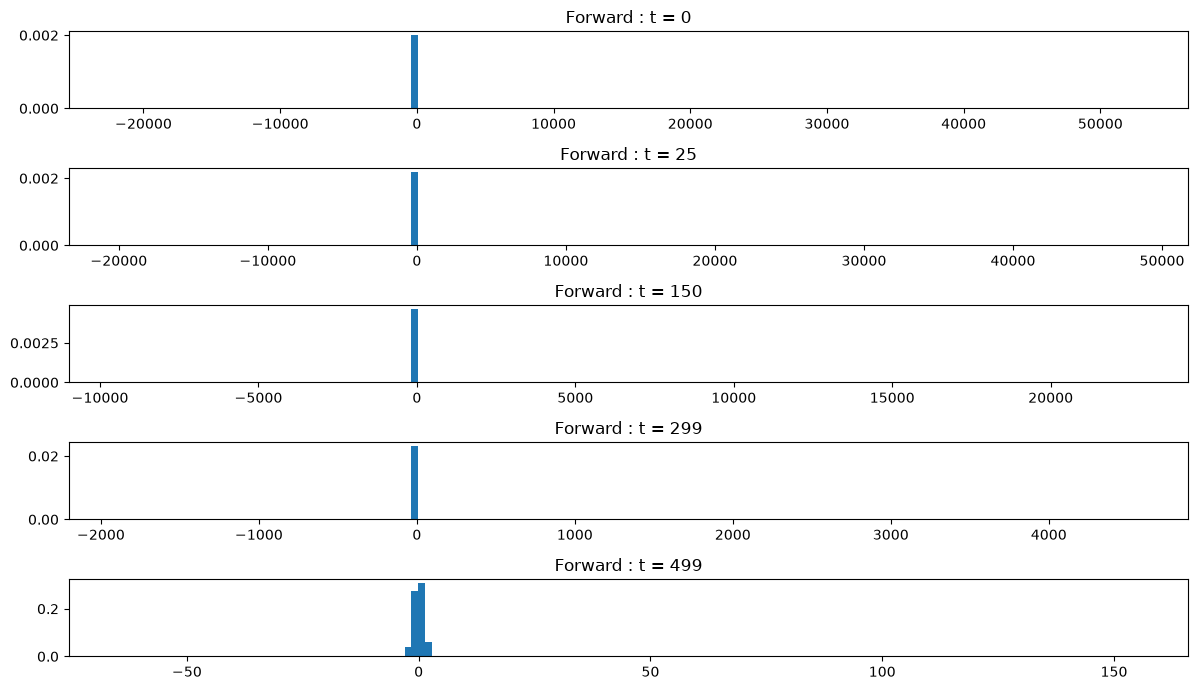

In [56]:
z0 = sample_data(30000, data=data)

times_to_plot = [0, 25, 150, 299, 499]

plt.figure(figsize=(12, 7))

for i, tt in enumerate(times_to_plot):
    t = torch.full((z0.shape[0],), tt, device=device, dtype=torch.long)
    zt, _ = q_sample(z0, t)
    zt_np = zt.detach().cpu().numpy()

    plt.subplot(len(times_to_plot), 1, i + 1)
    plt.hist(zt_np, bins=150, density=True)
    plt.title(f"Forward : t = {tt}")

plt.tight_layout()
plt.show()

Entrainement pour prédire le score

In [57]:

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2

        frequencies = torch.exp(
            -math.log(10000.0)
            * torch.arange(
                half_dim,
                device=t.device,
                dtype=torch.float32,
            )
            / max(half_dim - 1, 1)
        )

        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)

        embedding = torch.cat(
            [
                torch.sin(angles),
                torch.cos(angles),
            ],
            dim=1,
        )

        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))

        return embedding


class ScoreModel(nn.Module):
    """
    model(zt, t) retourne directement :

        score_theta(zt, t) ~= d/dz log p_t^Z(zt).

    Le réseau interne apprend la version stable :

        r_theta(zt, t)
        =
        sqrt(1 - alpha_bar_t) * score_theta(zt, t).
    """

    def __init__(
        self,
        alpha_bars,
        time_dim=64,
        hidden_dim=128,
    ):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_dim)

        self.register_buffer(
            "score_scales",
            torch.sqrt(
                (1.0 - alpha_bars).clamp_min(1e-8)
            ),
        )

        self.net = nn.Sequential(
            nn.Linear(1 + time_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, 1),
        )

        # Au départ, le score est proche de zéro.
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def normalized_score(self, zt, t):
        """
        Retourne r_theta = sigma_t * score_theta.

        Cette fonction est uniquement utilisée pendant
        l'entraînement pour éviter une division numérique
        par sigma_t.
        """
        t_embedding = self.time_embedding(t)

        inputs = torch.cat(
            [
                zt,
                t_embedding,
            ],
            dim=1,
        )

        return self.net(inputs)

    def forward(self, zt, t):
        """
        Cette sortie est utilisée directement par le sampler.
        """
        normalized_score = self.normalized_score(zt, t)

        sigma_t = extract(
            self.score_scales,
            t,
            zt.shape,
        ).clamp_min(1e-4)

        return normalized_score / sigma_t


model = ScoreModel(alpha_bars).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-6,
)

In [58]:
def sample_training_timesteps(batch_size):
    """
    Tirage non uniforme des temps.

    - 75 % : très concentré vers les petits temps.
    - 25 % : uniforme sur toute la chaîne.

    Cela donne beaucoup plus de signal aux temps proches
    de t = 0, sans perdre l'apprentissage des grands temps.
    """

    uniform_t = torch.randint(
        low=0,
        high=T,
        size=(batch_size,),
        device=device,
        dtype=torch.long,
    )

    u = torch.rand(
        batch_size,
        device=device,
    )

    early_t = torch.floor(
        T * u.pow(4)
    ).long()

    early_t = early_t.clamp(
        min=0,
        max=T - 1,
    )

    use_early_time = torch.rand(
        batch_size,
        device=device,
    ) < 0.85

    t = torch.where(
        use_early_time,
        early_t,
        uniform_t,
    )

    return t


def train_step(model, optimizer, batch_size):
    model.train()

    z0 = sample_data(
        batch_size,
        data=data,
    )

    t = sample_training_timesteps(batch_size)

    zt, eps = q_sample(z0, t)

    # r_theta = sigma_t * score_theta.
    #
    # Le score conditionnel est :
    #
    # grad_z log q(z_t | z_0) = -eps / sigma_t.
    #
    # Donc r_theta doit apprendre -eps.
    #
    # On évite explicitement tout calcul de -eps / sigma_t.
    normalized_score_prediction = model.normalized_score(
        zt,
        t,
    )

    loss = (
        normalized_score_prediction + eps
    ).square().mean()

    optimizer.zero_grad(set_to_none=True)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0,
    )

    optimizer.step()

    return loss.item()


losses = []

num_steps = 10000
batch_size = 1028

for step in range(num_steps):
    loss = train_step(
        model=model,
        optimizer=optimizer,
        batch_size=batch_size,
    )

    losses.append(loss)

    if (step + 1) % 500 == 0:
        print(
            f"step {step + 1:5d}"
            f" | loss = {loss:.6f}"
        )

step   500 | loss = 0.911898
step  1000 | loss = 0.734934
step  1500 | loss = 0.692804
step  2000 | loss = 0.689596
step  2500 | loss = 0.705557
step  3000 | loss = 0.655723
step  3500 | loss = 0.668732
step  4000 | loss = 0.694124
step  4500 | loss = 0.764994
step  5000 | loss = 0.701648
step  5500 | loss = 0.651584
step  6000 | loss = 0.688761
step  6500 | loss = 0.703895
step  7000 | loss = 0.663559
step  7500 | loss = 0.757938
step  8000 | loss = 0.717880
step  8500 | loss = 0.743945
step  9000 | loss = 0.753999
step  9500 | loss = 0.728655
step 10000 | loss = 0.704692


Sampling

In [59]:
RHO = 1
FD_STEP = 0.10

@torch.no_grad()
def p_sample_hidden_x_ddpm(model,zt, t):
    """
    Sample adapted but we use the actual Gaussian score of Z_t, which is known in this synthetic example.
    """

    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)
    alpha_bar_t = extract(
    alpha_bars,
    t,
    zt.shape,
        )
    # sigma_{t-1}^2
    sigma_prev2 = extract_sigma2(t, zt.shape)
    sigma_prev = torch.sqrt(sigma_prev2)
    # delta_t = beta_t + alpha_t * sigma_{t-1}^2
    delta_t = beta_t + alpha_t * sigma_prev2
    
    # Bias induced by E[epsilon_{t-1}] = eps_mean.
    # Z_t | X_{t-1}=x is N(sqrt(alpha_t)*(x + sigma_{t-1} eps_mean), delta_t I).
    bias_t = torch.sqrt(alpha_t) * sigma_prev * eps_mean

    # Score learned of f_t^Z
    score = model(zt, t)

    h_t = (
    FD_STEP
    * torch.sqrt(
        (1.0 - alpha_bar_t).clamp_min(1e-6)
    )
).clamp_min(0.05)

    # Différence finie centrale : aucune dérivée autograd
    score_plus = model(zt + h_t, t)
    score_minus = model(zt - h_t, t)

    score_derivative = (
        score_plus - score_minus
    ) / (2.0 * h_t)

    # Dérivée amortie : rho fixe
    score_derivative = RHO * score_derivative


    var_x_prev = (
    delta_t / alpha_t
) * (
    1.0 + delta_t * score_derivative
)
    var_x_prev = var_x_prev.clamp_min(1e-8)


    noise_x = torch.randn_like(zt)
    
    # 
    # Tweedie estimate: mean of X_{t-1} | Z_t
    x_prev_hat = (zt -bias_t + delta_t * score) / torch.sqrt(alpha_t)

    #Tweedie variance: var(X_{t-1} | Z_t) = delta_t / alpha_t

    x_prev = x_prev_hat + torch.sqrt(var_x_prev) * noise_x



    noise_z = torch.randn_like(zt)
    z_prev = x_prev + sigma_prev * eps_mean + torch.sqrt(sigma_prev2) * noise_z

    return z_prev, x_prev, x_prev_hat

In [60]:
@torch.no_grad()
def sample_hidden_x_from_z_ddpm( model, n_samples):
    """
    Full adapted reverse chain.

    Returns:
        x0_hat    : generated latent X_0
        z0_hat    : generated observed Z_0
        trajectory: selected intermediate states
    """
  
    zt = torch.randn(n_samples, 1, device=device)

    trajectory = []
    x_prev_hat = None

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)

        z_prev, x_prev, x_prev_hat= p_sample_hidden_x_ddpm(model, zt, t)

        if time_step in [T - 1, 200, 100, 50, 10, 0]:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),
                    "x_prev": x_prev.detach().cpu(),
                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),
                }
            )

        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev.detach().cpu()

    return x0_hat, z0_hat, trajectory

In [61]:

x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm(model, n_samples=30000)

x0_real, z0_real = sample_joint_data(30000, data=data)
x0_real = x0_real.detach().cpu()
z0_real = z0_real.detach().cpu()







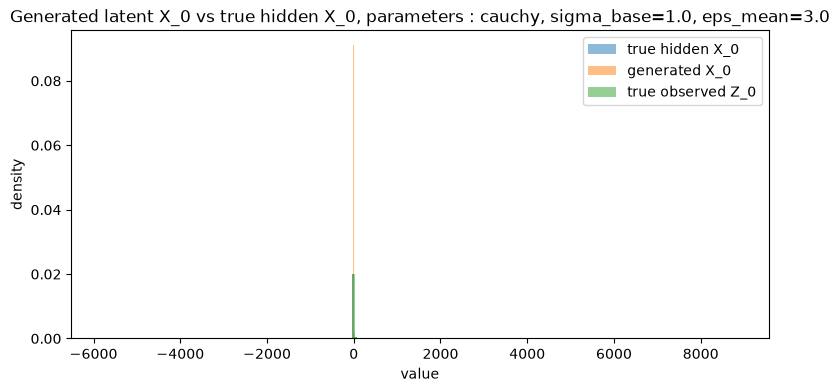

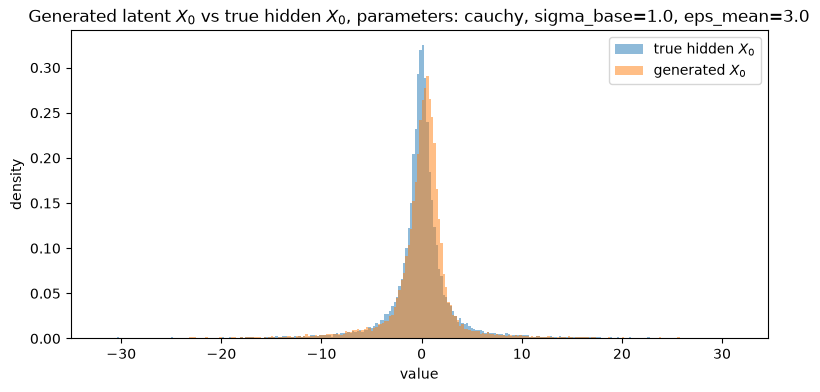

In [75]:
plt.figure(figsize=(9, 4))
plt.hist(x0_real.numpy(), bins=300, density=True, alpha=0.5, label="true hidden X_0")
plt.hist(x0_gen.numpy(), bins=300, density=True, alpha=0.5, label="generated X_0")
plt.hist(z0_real.numpy(), bins=300, density=True, alpha=0.5, label="true observed Z_0")
plt.title(f"Generated latent X_0 vs true hidden X_0, parameters : {data}, {sigma_base=}, {eps_mean=}")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

if data == "cauchy":
    all_values = np.concatenate([
        x0_real.numpy(),
        x0_gen.numpy(),
        z0_real.numpy(),
    ])

    xmin, xmax = np.quantile(all_values, [0.01, 0.99])

    padding = 0.05 * (xmax - xmin)
    xmin -= padding
    xmax += padding

else:
    xmin = min(
        x0_real.numpy().min(),
        x0_gen.numpy().min(),
        z0_real.numpy().min(),
    )

    xmax = max(
        x0_real.numpy().max(),
        x0_gen.numpy().max(),
        z0_real.numpy().max(),
    )

plt.figure(figsize=(9, 4))

plt.hist(
    x0_real.numpy(),
    bins=300,
    density=True,
    alpha=0.5,
    range=(xmin, xmax),
    label="true hidden $X_0$",
)

plt.hist(
    x0_gen.numpy(),
    bins=300,
    density=True,
    alpha=0.5,
    range=(xmin, xmax),
    label="generated $X_0$",
)

# plt.hist(
#     z0_real.numpy(),
#     bins=300,
#     density=True,
#     alpha=0.5,
#     range=(xmin, xmax),
#     label="true observed $Z_0$",
# )

plt.xlim(xmin, xmax)

plt.title(
    f"Generated latent $X_0$ vs true hidden $X_0$, "
    f"parameters: {data}, {sigma_base=}, {eps_mean=}"
)

plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()
    

# Comparison with a baseline : Normal backward on Z + Tweedie last step (with and without correcting the variance)

In [ ]:
# ============================================================
# Baseline: backward DDPM standard sur Z
#
# Le modèle fournit score_theta(z_t, t) ≈ ∂_z log p_t^Z(z_t).
# On utilise donc le reverse DDPM standard :
#
#   z_{t-1} ~ N(
#       (z_t + beta_t * score_theta(z_t, t)) / sqrt(alpha_t),
#       beta_t_tilde
#   )
#
# avec beta_t_tilde = beta_t (1-alpha_bar_{t-1})/(1-alpha_bar_t).
# ============================================================

alpha_bars_prev = torch.cat(
    [
        torch.ones(
            1,
            device=device,
            dtype=alpha_bars.dtype,
        ),
        alpha_bars[:-1],
    ],
    dim=0,
)

posterior_variances_ddpm = (
    betas
    * (1.0 - alpha_bars_prev)
    / (1.0 - alpha_bars).clamp_min(1e-12)
)

# Au dernier pas t=0, le reverse DDPM est déterministe.
posterior_variances_ddpm[0] = 0.0


@torch.no_grad()
def p_sample_z_ddpm_standard(model, zt, t):
    """
    Un pas reverse DDPM standard pour Z_t -> Z_{t-1}.
    """
    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)

    posterior_var_t = extract(
        posterior_variances_ddpm,
        t,
        zt.shape,
    )

    score_t = model(zt, t)

    mean = (
        zt + beta_t * score_t
    ) / torch.sqrt(alpha_t)

    # Pas de bruit au dernier pas t=0.
    nonzero_mask = (
        (t != 0)
        .float()
        .reshape(-1, *([1] * (zt.ndim - 1)))
    )

    noise = torch.randn_like(zt)

    return mean + nonzero_mask * torch.sqrt(
        posterior_var_t.clamp_min(0.0)
    ) * noise


@torch.no_grad()
def sample_z_ddpm_standard(model, n_samples):
    """
    Génère une population de Z_0 avec un backward DDPM standard.
    """
    model.eval()

    zt = torch.randn(
        n_samples,
        1,
        device=device,
    )

    for time_step in reversed(range(T)):
        t = torch.full(
            (n_samples,),
            time_step,
            device=device,
            dtype=torch.long,
        )

        zt = p_sample_z_ddpm_standard(
            model,
            zt,
            t,
        )

    return zt


n_baseline_samples = n_samples

z0_ddpm = sample_z_ddpm_standard(
    model,
    n_samples=n_baseline_samples,
)

print("z0_ddpm shape:", tuple(z0_ddpm.shape))

In [ ]:
# ============================================================
# dernière étape de Tweedie : Z_0 -> X_0

# Ici on part des 
#
# Z_0 = X_0 + sigma_base * eps_0
# eps_0 ~ N(eps_mean, 1)
#
# Moyenne de Tweedie :
#
# E[X_0 | Z_0=z]
# = z - sigma_base * eps_mean + sigma_base^2 * score_Z(z).
#
# Sans correction :
# Var[X_0 | Z_0=z] ≈ sigma_base^2.
#
# Avec correction :
# Var[X_0 | Z_0=z]
# = sigma_base^2 + sigma_base^4 * d(score_Z)/dz.
# ============================================================


@torch.no_grad()
def tweedie_last_step_x0(
    model,
    z0,
    correct_variance=False,
    fd_step=FD_STEP,
):
    """
    Transforme des Z_0 générés en X_0 générés.

    Returns
    -------
    x0_sample : échantillons générés de X_0
    x0_mean   : moyenne de Tweedie E[X_0 | Z_0]
    cond_var  : variance utilisée
    """
    if sigma_base <= 0:
        raise ValueError(
            "sigma_base doit être strictement positif."
        )

    if fd_step <= 0:
        raise ValueError(
            "fd_step doit être strictement positif."
        )

    model.eval()

    t0 = torch.zeros(
        z0.shape[0],
        device=z0.device,
        dtype=torch.long,
    )

    score_z0 = model(z0, t0)

    # Moyenne a posteriori de Tweedie.
    x0_mean = (
        z0
        - sigma_base * eps_mean
        + sigma_base**2 * score_z0
    )

    if correct_variance:
        # Dérivée du score par différence finie comme au dessus
        h = torch.full_like(
            z0,
            fd_step,
        )

        score_plus = model(z0 + h, t0)
        score_minus = model(z0 - h, t0)

        score_derivative = (
            score_plus - score_minus
        ) / (2.0 * h)

        cond_var = (
            sigma_base**2
            + sigma_base**4 * RHO*score_derivative
        )

        cond_var = cond_var.clamp_min(1e-8)

    else:

        cond_var = torch.full_like(
            z0,
            sigma_base**2,
        )

    x0_sample = (
        x0_mean
        + torch.sqrt(cond_var) * torch.randn_like(z0)
    )

    return x0_sample, x0_mean, cond_var


# Version avec correction de variance de Tweedie.
x0_tweedie_variance_corrected, _, var_corrected = (
    tweedie_last_step_x0(
        model,
        z0_ddpm,
        correct_variance=True,
    )
)



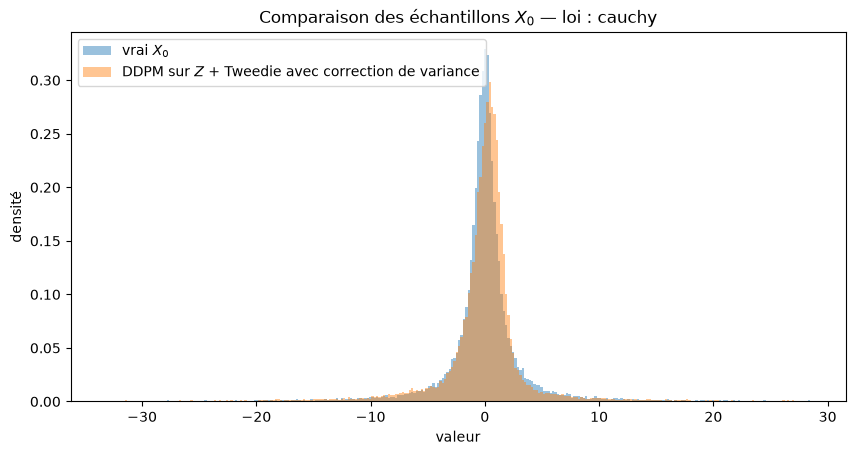

In [79]:

n_baseline_samples = n_samples
# Population de référence suivant la vraie loi de X_0 choisie.
x0_reference, _ = sample_joint_data(
    n_baseline_samples,
    data=data,
)

x0_reference_np = (
    x0_reference.detach().cpu().numpy().ravel()
)



x0_corrected_np = (
    x0_tweedie_variance_corrected
    .detach()
    .cpu()
    .numpy()
    .ravel()
)


values_for_window = np.concatenate(
    [
        x0_reference_np,

        x0_corrected_np,
    ]
)

xmin, xmax = np.quantile(
    values_for_window,
    [0.01, 0.99],
)

padding = 0.05 * max(xmax - xmin, 1e-6)

plt.figure(figsize=(10, 4.8))

plt.hist(
    x0_reference_np,
    bins=300,
    density=True,
    range=(xmin, xmax),
    alpha=0.45,
    label="vrai $X_0$",
)


plt.hist(
    x0_corrected_np,
    bins=300,
    density=True,
    range=(xmin, xmax),
    alpha=0.45,
    label="DDPM sur $Z$ + Tweedie avec correction de variance",
)

plt.xlim(
    xmin - padding,
    xmax + padding,
)

plt.title(
    f"Comparaison des échantillons $X_0$ — loi : {data}"
)

plt.xlabel("valeur")
plt.ylabel("densité")
plt.legend()
plt.show()

# COmparison beteen the 2 methods

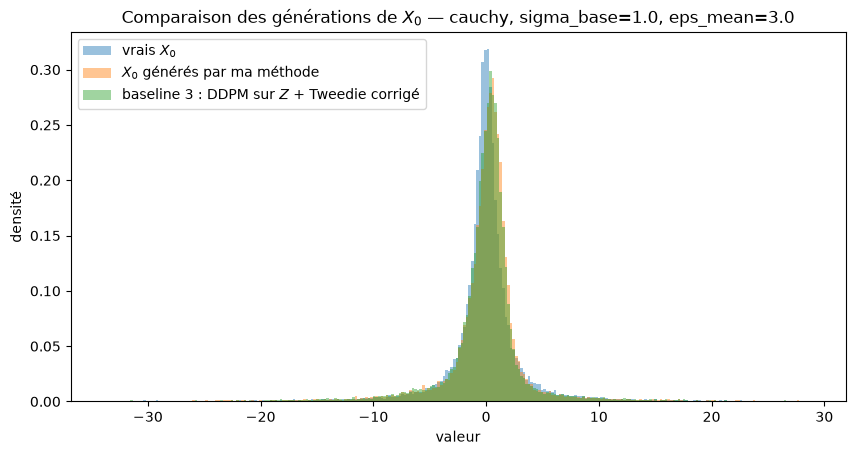

In [ ]:
# ============================================================
# Comparaison :
# - vrais X_0
# - X_0 générés par notre méthode
# - X_0 générés par la baseline 
# ============================================================

# Baseline  :
# DDPM standard sur Z, puis Tweedie avec correction de variance.
x0_baseline3 = x0_tweedie_variance_corrected

# Passage en NumPy, compatible CPU / GPU et tenseurs avec gradients.
x0_real_np = x0_real.detach().cpu().numpy().ravel()
x0_gen_np = x0_gen.detach().cpu().numpy().ravel()
x0_baseline3_np = (
    x0_baseline3.detach().cpu().numpy().ravel()
)



all_values = np.concatenate([
    x0_real_np,
    x0_gen_np,
    x0_baseline3_np,
])

if data == "cauchy":

    xmin, xmax = np.quantile(
        all_values,
        [0.01, 0.99],
    )

else:
    xmin = all_values.min()
    xmax = all_values.max()

padding = 0.05 * max(xmax - xmin, 1e-8)

xmin_plot = xmin - padding
xmax_plot = xmax + padding

# ------------------------------------------------------------
# Histogrammes
# ------------------------------------------------------------

plt.figure(figsize=(10, 4.8))

plt.hist(
    x0_real_np,
    bins=300,
    density=True,
    alpha=0.45,
    range=(xmin_plot, xmax_plot),
    label="vrais $X_0$",
)

plt.hist(
    x0_gen_np,
    bins=300,
    density=True,
    alpha=0.45,
    range=(xmin_plot, xmax_plot),
    label="$X_0$ générés par ma méthode",
)

plt.hist(
    x0_baseline3_np,
    bins=300,
    density=True,
    alpha=0.45,
    range=(xmin_plot, xmax_plot),
    label="baseline 3 : DDPM sur $Z$ + Tweedie corrigé",
)

plt.xlim(xmin_plot, xmax_plot)

plt.title(
    f"Comparaison des générations de $X_0$ — "
    f"{data}, {sigma_base=}, {eps_mean=}"
)

plt.xlabel("valeur")
plt.ylabel("densité")
plt.legend()
plt.show()